### UE ADSP

**A**nalogical and **D**igital **S**ignal **P**rocessing for sensor data

### TP 6 : Algorithme Kalman

1. But du TP

Le but de ce TP consiste à tester l'algorithme de Kalman est d'en comprendre le fonctionnement

- Construction les données
- Initialisation des modèles et des variables
- Algorithme de Kalman
- Lissage du résultat

Import des librairies

In [7]:
# les import numpy, matplotlib, math
import numpy as np
import matplotlib.pyplot as plt
import math

On va initialiser une trajectoire 2D ($X_{ref}$) en forme de spirale.

Soit

$$
X_{ref}=\sqrt{t}\begin{bmatrix}\cos(2\pi f_0t)\\ \sin(2\pi f_0t)\end{bmatrix}
$$

désigne la trajectoire d'un point dans un espace 2D, avec $t=1:nb$. La vitesse correspondante sera calculée à l'aide de la différence finie. Une version bruitée de la trajectoire et de sa vitesse est observée . La matrice de covariance du bruit est sous la forme ${\bf \Sigma}_n=\sigma_n^2\mathbb{I}_4$. $A(n)=\begin{bmatrix}a_x(n)\\ a_y(n)\end{bmatrix}$


Nous modélisons le système à l'aide d'un modèle cinématique simple sous la forme d'un modèle d'espace d'état où le vecteur d'état se compose de la position, de la vitesse et de l'accélération du point (comme dans la leçon). L'accélération est modélisée par un $AR(1)$ processus : $A(n+1)=\rho A(n)+v_{A,n}$ avec ${\bf \Sigma}_{v_A}=\sigma_{v_A}^2\mathbb{I}_2$. 

Nous écrirons le modèle 
- **Equation d'état**
 
$$X(n+1)={\bf F}(n) X(n) + W(n)$$

$W(n)$ : bruit blanc, Matrice de covariance $Q$

Dans ce tp $B(n)$ est nulle et ${\bf F}$ ne varie pas avec $n$.

- **Equation d'observation**

$$Y(n) = {\bf H}(n) X(n) + V(n)$$

$V(n)$ : bruit de mesure/d'observation de matrice de covariance $R$

Dans ce TP, ${\bf H}$ ne varie pas avec $n$.

>- 1) Tracez les trajectoires de référence et celles bruitées de position et de vitesse avec $nb=200$ et $f_0=2/nb$ ;
>- 2) Donner l'expression de ${\bf F}$ and ${\bf H}$ et donner les expressions des matrices ${\bf D}_Q$ et ${\bf D}_R$ dans les matrices de covariances ${\bf Q}=cov[{\bf G} v(n)]=σ_v^2 {\bf D}_Q$ et ${\bf R}=cov[{\bf U} b(n)]=σ_b^2 {\bf D}_R$ ;
>- 3) Denoting by  ${\bf K}$, ${\bf P}\_$ and ${\bf P}$ the Kalman gain, and covariance matrices of prediction and filtering errors respectively implement the Kalman filter;
>- 4) Plot the trajectories of position and speed estimated using the Kalman filter. Check the robustness of the estimation with respect to the choice of the parameters of the model;
>- 5) Implement Kalman smoother and check the improvment brought compared to the Kalman filter.

1. Construire et tracer les trajectoire

Le nombre de points de la trajectoire est égal à 200.

Le pas d'échantillonnage est de 1 seconde.

Voici la trajectoire de référence

$$
\begin{bmatrix}x \\ y  \end{bmatrix}=\sqrt{t}\begin{bmatrix}\cos(2\pi t / (nb/2))\\ \sin(2\pi t / (nb/2))\end{bmatrix}
$$

On en déduit la vitesse par différence entre 2 valeurs qui se suivent (on suppose que la vitesse à l'instant 0 est égale à celle de l'instant 1.

On construit l'observation : 

$$Y = \begin{bmatrix}x \\ y \\ vx \\ vy \end{bmatrix} +  \sigma_b v(n)$$

où $v(n)$ est un bruit blanc gaussien (de dimension 1x4) de variance $var_b$ qui est égale à 1.

- définir les vecteurs x et y (position)
- définir les vecteur vx et vy (vitesse) en $vx(n)=x(n)-x(n-1)$, $vy(n)=y(n)-y(n-1)$, $vx(0)=vx(1)$, $vy(0)=vy(1)$

- definir le vecteur $Y = \begin{bmatrix}x \\ y \\ vx \\ vy \end{bmatrix}$
- bruiter le signal le vecteur $Y$ avec un bruit blanc gaussien de variance $\sigma_b=1$

type : <class 'numpy.ndarray'>  ; dimension : (4, 200)


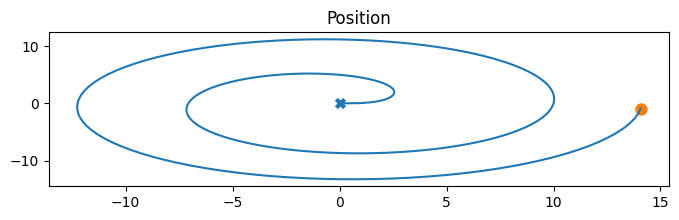

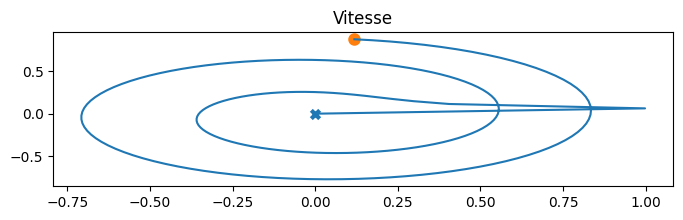

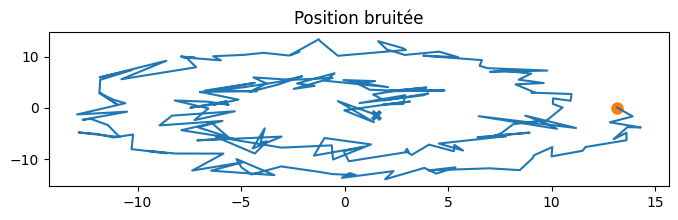

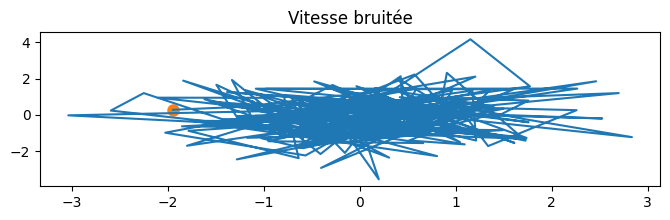

In [8]:
# Ecrire les equations du modele d'Ètat et d'observation
# analytiquement. Est-ce un modele compatible pour une implémentation de
# de Kalman
nb = 200 # nombre de points
t = np.arange(0,nb)
var_a = 0.001
var_b = 1

# création de la trajection
# np.sqrt et np.cos
x = np.zeros(nb)
y = np.zeros(nb)
x = np.sqrt(t) * np.cos(2*np.pi*t/(nb/2))
y = np.sqrt(t) * np.sin(2*np.pi*t/(nb/2))

# vitesse
vx = np.zeros(nb)
vy = np.zeros(nb)
vx[1:nb] = np.diff(x)          
vy[1:nb] = np.diff(y)
vx[0] = 0
vy[0] = 0

# création de l'observation
# bruitage en utilisant np.random.randn
Y = np.vstack((x, y, vx, vy)) # creer Y avec x, y, vx, vy
Y = Y + var_b * np.random.randn(4, nb)
print("type :",type(Y)," ; dimension :", Y.shape)

plt.figure(figsize=(8, 2))
plt.title("Position")
plt.plot(x, y)
plt.scatter(x[0], y[0], marker = 'x', linewidths=3)
plt.scatter(x[nb-1], y[nb-1], marker = 'o', linewidths=3)

plt.figure(figsize=(8, 2))
plt.title("Vitesse")
plt.plot(vx, vy)
plt.scatter(vx[0], vy[0], marker = 'x', linewidths=3)
plt.scatter(vx[nb-1], vy[nb-1], marker = 'o', linewidths=3)

plt.figure(figsize=(8, 2))
plt.title("Position bruitée")
plt.plot(Y[0, :], Y[1, :])
plt.scatter(Y[0, 0], Y[1, 0], marker = 'x', linewidths=3)
plt.scatter(Y[0, nb-1], Y[1, nb-1], marker = 'o', linewidths=3)

plt.figure(figsize=(8, 2))
plt.title("Vitesse bruitée")
plt.plot(Y[2, :], Y[3, :])
plt.scatter(Y[2, 0], Y[3, 0], marker = 'x', linewidths=3)
plt.scatter(Y[2, nb-1], Y[3, nb-1], marker = 'o', linewidths=3)
plt.show()


2. Définition des modèles d'états et initialisation des matrices

$$X(n)=\begin{bmatrix}x \\ y\\
              v_x\\ v_y\\
              a_x\\ a_y \end{bmatrix}$$

Définition des modèles d'état et d'observation 

$$X(n+1)= {\bf F} X(n) + W(n)$$

$X(n)$ est l'état interne du système à l'instant $n$. Il contient la position, la vitesse et l'accelaration (en 2D) à l'instant $n$

$${\bf F} = \begin{bmatrix}1 & 0 & 1& 0& 0& 0 \\ 0& 1& 0& 1& 0& 0\\
              0& 0& 1& 0& 1& 0\\ 0& 0& 0& 1& 0& 1\\
              0& 0& 0& 0& \rho & 0\\ 0& 0& 0& 0& 0& \rho \end{bmatrix}$$

- Equation d'observation

$$Y(n) = {\bf H} X(n)+V(n)$$
avec 
$${\bf H} = \begin{bmatrix} 1& 0& 0& 0& 0& 0 \\ 0& 1& 0& 0& 0& 0 \\0& 0& 1& 0& 0& 0 \\0& 0& 0& 1& 0& 0 \end{bmatrix}$$

permet d'observer la position et la vitesse.

- Définir H et F qui sont des np.array

- Définir Q et R

$${\bf Q}=\sigma_a^2 \begin{bmatrix}0 & 0 & 0& 0& 0& 0 \\ 0& 0& 0& 0& 0& 0\\
              0& 0& 0& 0& 0& 0\\ 0& 0& 0& 0& 0& 0\\
              0& 0& 0& 0& 1 & 0\\ 0& 0& 0& 0& 0& 1 \end{bmatrix}$$

$${\bf R} = \sigma^2_b \begin{bmatrix}1 & 0 & 0& 0 \\ 0& 1& 0& 0 \\
              0& 0& 1& 0\\ 0& 0& 0& 1 \end{bmatrix}$$

In [9]:
rho   = 0.2

# initialisation des matrices de covariance
# matrice de covariance de l'état
Q =  np.array([[0, 0, 0, 0, 0, 0],
               [0, 0, 0, 0, 0, 0],
               [0, 0, 0, 0, 0, 0],
               [0, 0, 0, 0, 0, 0],
               [0, 0, 0, 0, 1, 0],
               [0, 0, 0, 0, 0, 1]]) * var_a
#Q = Qv
print("Q :")
print(Q)
# matrice de covariance de l'observation
R = np.eye(4) * var_b
#R = Qw
print("R :")
print(R)
# Matrice de transistion
F = np.array([[1, 0, 1, 0, 0,   0],
              [0, 1, 0, 1, 0,   0],
              [0, 0, 1, 0, 1,   0],
              [0, 0, 0, 1, 0,   1],
              [0, 0, 0, 0, rho, 0],
              [0, 0, 0, 0, 0,   rho]])
print("F :")
print(F)

# Matrice d'observation
H = np.array([[1, 0, 0, 0, 0, 0],
              [0, 1, 0, 0, 0, 0],
              [0, 0, 1, 0, 0, 0],
              [0, 0, 0, 1, 0, 0]])
print("H :")
print(H)

Q :
[[0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.001 0.   ]
 [0.    0.    0.    0.    0.    0.001]]
R :
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
F :
[[1.  0.  1.  0.  0.  0. ]
 [0.  1.  0.  1.  0.  0. ]
 [0.  0.  1.  0.  1.  0. ]
 [0.  0.  0.  1.  0.  1. ]
 [0.  0.  0.  0.  0.2 0. ]
 [0.  0.  0.  0.  0.  0.2]]
H :
[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]]


Algorithme de Kalman

- Initialiser :
   - $X(0|-1) = 0$,
   - $P(0|-1) = I_{6x6}$,

- Phase de prédiction
   - $X(n|n−1) = F \cdot X(n−1|n−1)$
   - $P(n|n−1) = F \cdot P(n−1|n−1)\cdot F^T + Q$ (estimation prédite de la covariance)
   - $Q$ matrice de covariance du bruit d'évolution

- Phase de mise à jour
   - $X(n|n) = X(n|n−1) + K(n)\cdot \left(Y(n) − H \cdot X(n|n−1)\right)$
     
- Calculs de $K(n)$

   - $X(n|n−1) = F \cdot X(n−1|n−1)$ (prediction)

   - $ P(n|n−1) = F \cdot P(n−1|n−1) \cdot F^T + Q$ avec $Q$ matrice de covariance du bruit d'évolution (estimation prédite de la covariance)

   - $K(n) = P(n|n−1) H^T\cdot [H \cdot P(n|n−1)\cdot H^T + R ]^{−1} $ avec $R$ matrice de covariance de bruit de mesure (gain de kalman)
 
   - $S(n)=H \cdot P(n|n−1) H^T + R$ (covariance de l'innovation)

   - $X(n|n) = X(n|n−1) + K(n)\cdot [Y(n) − H\cdot X(n,n-1)]$ (mise à jour)
 
   - $\tilde{y}(n) = Y(n) − H\cdot X(n,n-1)$ (innovation)

   - $P(n|n) =[I- K(n)\cdot H]\cdot P(n|n-1) $ (covariance de la mise à jour)


where $P(n|n−1) = cov(X(n) − X(n|n−1)$ and $P(n|n) = cov(X(n) − X(n|n)$.

On appelera :
- $X(n|n)$ : Xnf
- $X(n+1|n)$ : Xnf_
- $P(n|n-1)$ : PP
- $P(n|n)$ : PF

- On stocke $P(n|n)$, $P(n|n-1)$, $|P(n|n)|$ dans les matrices stor_PF, stor_PF et err, les initialiser avec la première valeur de $P(n|n)$, $P(n|n-1)$, $|P(n|n)|$.

### Initialisation - première itération

On commence par effectuer les initialisations et la première itération

Les fonctions suivantes pouraient être utiles : 

*.transpose*, *.dot*, *.reshape*, *numpy.linalg.inv*, *numpy.linalg.norm*

In [10]:
# X(0|-1)=0
Xnf_ = np.zeros((6, 1))  

# Calculde P(0|-1) nommé PP
PP = np.eye(6)     # estimation prédite de la covariance Identité 6x6

# calcul de K
TT = H@PP@H.T + R # TT = H.P(0|-1).H'+R
K = PP@H.T@np.linalg.inv(H@PP@H.T + R)  # K = P(0|-1).H'.(H.P(0|-1).H'+R)^(-1)

# innovation
# XX1 = Y(:,0) - H. X(0|-1)
# attention Y est de dimension 4xnb
# utlisation de reshape((4,1)) doit être appliqué suy Y[:,0]
XX1 = Y[:, 0] - H@Xnf_
# mise à jour
# de X(0|0)
Xnf = Xnf_ + K@(Y[:, 0].reshape((4,1)) - H@Xnf_) # X(0|0) =  X(0|-1) + K . [Y[0] - H . X(0|-1)]

est_f = Xnf # X(0|0)   matrice des vecteurs d'etat filtres stockage des etats

### P(0|0) (I-K.H). P(0|-1) 

# de P(0,0)
PF = (np.eye(6) - K@H)@PP          # (I-K H).P(0|-1)

# prediction
# de X(1,0)
Xnf_ = F @ Xnf # X(1|0) = F . X(0|0)

# Initialisation du stockage des matrices contenant les P(n,n), P(n,n-1), |P(n,n)|
err = np.zeros(1)
err[0] = np.linalg.norm(PF, ord=2)
err.reshape(1)

stor_PP = PP
stor_PF = PF

## Filtrage (boucle)

- On parcourt (on boucle) maintenant l'ensemble du signal.

On appelera :
- $X(n|n)$ : Xnf
- $X(n+1|n)$ : Xnf_
- $P(n|n-1)$ : PP
- $P(n|n)$ : PF

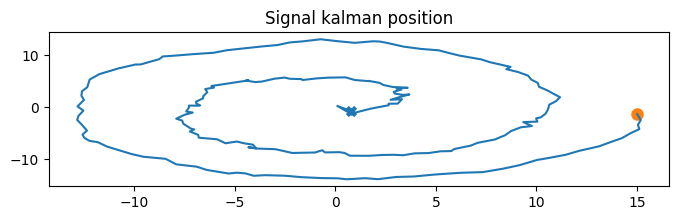

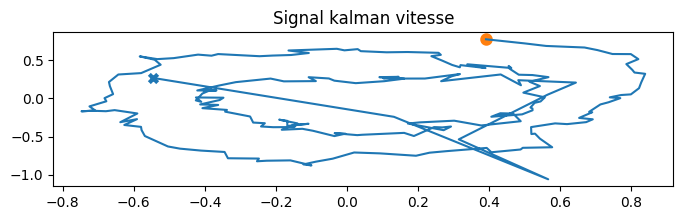

In [11]:
errt = np.zeros(1)
for n in range(1, nb):
    
    # calcul d
    PP = F @ PF @ F.T + Q # P(n|n-1) = F . P(n-1|n-1) . F' + Q
    
    # calcul de K 
    K = PP @ H.T @ np.linalg.inv(H @ PP @ H.T + R) # K = P(n|n-1) . H'.(H .P(n|n-1).H'+Q)^(-1)

    # innovation
    XX1 = Y[:, n].reshape((4, 1)) - H @ Xnf_ ## TT1 = (Y[n]-H.X(n|n-1))

    # mise à jour
    Xnf = Xnf_ + K @ XX1  # X(n|n)=X(n|n-1)+K.(Y[n]-H.X(n|n-1))
    
    est_f = np.concatenate((est_f, Xnf), axis=1)  # concatene les etats filtrés

    ### P(k|k)=(I-K.H).P(k|k-1)
    PF = (np.eye(6) - K @ H) @ PP          # (I-K.H).P(k|k-1)
    
    # prediction
    Xnf_ = F.dot(Xnf)  # X(n+1,n) = F. X(n|n)
    
    errt[0]= np.linalg.norm(PF, ord = 2)
    err = np.concatenate((err, errt), axis=0)
    stor_PP = np.concatenate((stor_PP, PP), axis=1)
    stor_PF = np.concatenate((stor_PF, PF), axis=1)

# affichage des résultats
plt.figure(figsize=(8, 2))
plt.title("Signal kalman position")
plt.plot(est_f[0, :], est_f[1, :])
plt.scatter(est_f[0, 0], est_f[1, 0], marker = 'x', linewidths=3)
plt.scatter(est_f[0, nb-1], est_f[1, nb-1], marker = 'o', linewidths=3)

plt.figure(figsize=(8, 2))
plt.title("Signal kalman vitesse")
plt.plot(est_f[2, :], est_f[3, :])
plt.scatter(est_f[2, 0], est_f[3, 0], marker = 'x', linewidths=3)
plt.scatter(est_f[2, nb-1], est_f[3, nb-1], marker = 'o', linewidths=3)

plt.show()


## Lissage


**Rauch-Tung-Striebel smoother**

Le lisseur Rauch-Tung-Striebel (RTS) est un algorithme efficace à deux passes pour le lissage à intervalle fixe.

La passe avant est la même que l'algorithme de filtre Kalman régulier. Ces estimations filtrées de l'état a-priori et a-posteriori
${\hat {\mathbf {x} }}_{n\mid n-1}$, ${\hat {\mathbf {x} }}_{n\mid n}$ et les covariances
$\mathbf {P} _{n\mid n-1}$, $ \mathbf {P} _{n\mid n}$ sont enregistrés pour être utilisés dans la passe arrière (pour la rétrodiction).

Dans le passage arrière, nous calculons les estimations de l'état lissé
$ {\hat {\mathbf {x} }}_{k\mid n}$ et les covariances
$ \mathbf {P} _{k\mid n}$. Nous commençons à la dernière étape et reculons dans le temps en utilisant les équations récursives suivantes :

$$ {\begin{aligned}{\hat {\mathbf {x} }}_{k\mid n}&={\hat {\mathbf {x} }}_{k\mid k}+\mathbf {C} _{k}\left({\hat {\mathbf {x} }}_{k+1\mid n}-{\hat {\mathbf {x} }}_{k+1\mid k}\right)\\\mathbf {P} _{k\mid n}&=\mathbf {P} _{k\mid k}+\mathbf {C} _{k}\left(\mathbf {P} _{k+1\mid n}-\mathbf {P} _{k+1\mid k}\right)\mathbf {C} _{k}^{\textsf {T}}\end{aligned}}$$
Où

$$ \mathbf {C} _{k}=\mathbf {P} _{k\mid k}\mathbf {F} _{k+1}^{\textsf {T}}\mathbf {P} _{k+1\mid k}^{-1}.$$

$ \mathbf {x} _{k\mid k}$ est l'estimation de l'état a-posteriori de pas
$k$ et
$ \mathbf {x} _{k+1\mid k}$ est l'estimation de l'état a priori de l'étape de temps
$k+1$. La même notation s'applique à la covariance.


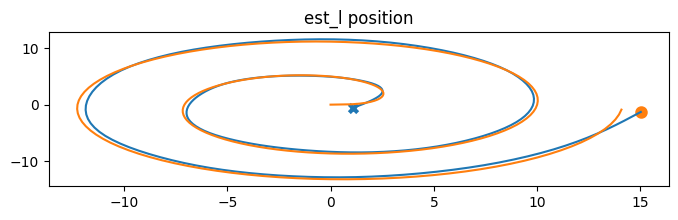

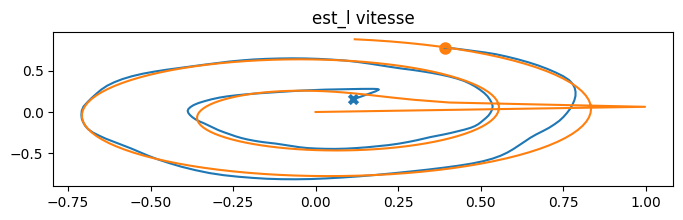

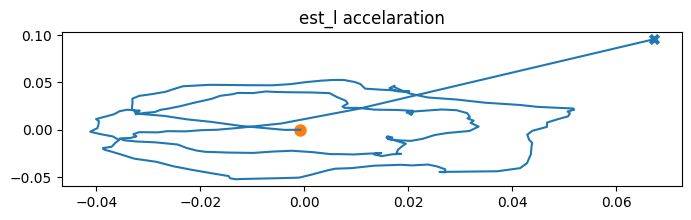

In [12]:

lPP = PP.shape[0]
cPP = PP.shape[1]
lPF = PF.shape[0]
cPF = PF.shape[1]
est_l = np.copy(Xnf)   # initialize with last filtered state X(nb-1|nb-1)
P_smooth = np.copy(PF)  # initialize with last filtered covariance P(nb-1|nb-1)

# lissage (RTS smoother)
# -----------------------
for k in range(nb-2, -1, -1):
    PFk = np.copy(stor_PF[:, k*cPF:(k+1)*cPF])          # P(k|k)
    PPp = np.copy(stor_PP[:, (k+1)*cPP:(k+2)*cPP])      # P(k+1|k)
    C = PFk.dot(F.transpose()).dot(np.linalg.inv(PPp))   # C_k = P(k|k).F^T.P(k+1|k)^{-1}
    Xnl = est_f[:, k] + C.dot(est_l[:, 0] - F.dot(est_f[:, k]))  # X_smooth(k)
    est_l = np.concatenate((Xnl.reshape((6, 1)), est_l), axis=1)
    P_smooth = PFk + C.dot(P_smooth - PPp).dot(C.T)     # P_smooth(k)

plt.figure(figsize=(8, 2))
plt.title("est_l position")
plt.plot(est_l[0, :], est_l[1, :])
plt.plot(x, y)
plt.scatter(est_l[0, 0], est_l[1, 0], marker = 'x', linewidths=3)
plt.scatter(est_l[0, nb-1], est_l[1, nb-1], marker = 'o', linewidths=3)


plt.figure(figsize=(8, 2))
plt.title("est_l vitesse")
plt.plot(est_l[2, :], est_l[3, :])
plt.plot(vx, vy)
plt.scatter(est_l[2, 0], est_l[3, 0], marker = 'x', linewidths=3)
plt.scatter(est_l[2, nb-1], est_l[3, nb-1], marker = 'o', linewidths=3)

plt.figure(figsize=(8, 2))
plt.title("est_l accelaration")
plt.plot(est_l[4, :], est_l[5, :])
plt.scatter(est_l[4, 0], est_l[5, 0], marker = 'x', linewidths=3)
plt.scatter(est_l[4, nb-1], est_l[5, nb-1], marker = 'o', linewidths=3)

plt.show()


## Analyse comparative : Signal bruité, Filtre de Kalman, Lisseur RTS

On va maintenant comparer quantitativement les trois estimations :
- **Observation bruitée** $Y$
- **Filtre de Kalman** $\hat{X}(n|n)$
- **Lisseur RTS** $\hat{X}(n|N)$

On utilise l'**erreur quadratique moyenne (RMSE)** pour la position et la vitesse :

$$\text{RMSE}_\text{pos} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left[(x(n)-\hat{x}(n))^2 + (y(n)-\hat{y}(n))^2\right]}$$

In [13]:
# ── 1. Calcul des erreurs RMSE ────────────────────────────────────────────────

# Référence vraie
x_ref  = x        # position x  (nb,)
y_ref  = y        # position y
vx_ref = vx       # vitesse vx
vy_ref = vy       # vitesse vy

# ---- Observation bruitée ----
rmse_pos_noisy = np.sqrt(np.mean((Y[0,:] - x_ref)**2 + (Y[1,:] - y_ref)**2))
rmse_vel_noisy = np.sqrt(np.mean((Y[2,:] - vx_ref)**2 + (Y[3,:] - vy_ref)**2))

# ---- Filtre de Kalman ----
rmse_pos_kalman = np.sqrt(np.mean((est_f[0,:] - x_ref)**2 + (est_f[1,:] - y_ref)**2))
rmse_vel_kalman = np.sqrt(np.mean((est_f[2,:] - vx_ref)**2 + (est_f[3,:] - vy_ref)**2))

# ---- Lisseur RTS ----
rmse_pos_smooth = np.sqrt(np.mean((est_l[0,:] - x_ref)**2 + (est_l[1,:] - y_ref)**2))
rmse_vel_smooth = np.sqrt(np.mean((est_l[2,:] - vx_ref)**2 + (est_l[3,:] - vy_ref)**2))

# ── 2. Tableau récapitulatif ───────────────────────────────────────────────────
print("=" * 52)
print(f"{'Méthode':<22} {'RMSE position':>14} {'RMSE vitesse':>13}")
print("-" * 52)
print(f"{'Signal bruité':<22} {rmse_pos_noisy:>14.4f} {rmse_vel_noisy:>13.4f}")
print(f"{'Filtre de Kalman':<22} {rmse_pos_kalman:>14.4f} {rmse_vel_kalman:>13.4f}")
print(f"{'Lisseur RTS':<22} {rmse_pos_smooth:>14.4f} {rmse_vel_smooth:>13.4f}")
print("=" * 52)

gain_k = (rmse_pos_noisy - rmse_pos_kalman) / rmse_pos_noisy * 100
gain_s = (rmse_pos_noisy - rmse_pos_smooth) / rmse_pos_noisy * 100
print(f"\nRéduction RMSE position  (Kalman vs bruité)  : {gain_k:.1f} %")
print(f"Réduction RMSE position  (Lisseur vs bruité) : {gain_s:.1f} %")
print(f"Amélioration lisseur sur filtre              : {(rmse_pos_kalman-rmse_pos_smooth)/rmse_pos_kalman*100:.1f} %")

Méthode                 RMSE position  RMSE vitesse
----------------------------------------------------
Signal bruité                  1.4637        1.4385
Filtre de Kalman               1.0741        0.2958
Lisseur RTS                    0.4030        0.0928

Réduction RMSE position  (Kalman vs bruité)  : 26.6 %
Réduction RMSE position  (Lisseur vs bruité) : 72.5 %
Amélioration lisseur sur filtre              : 62.5 %


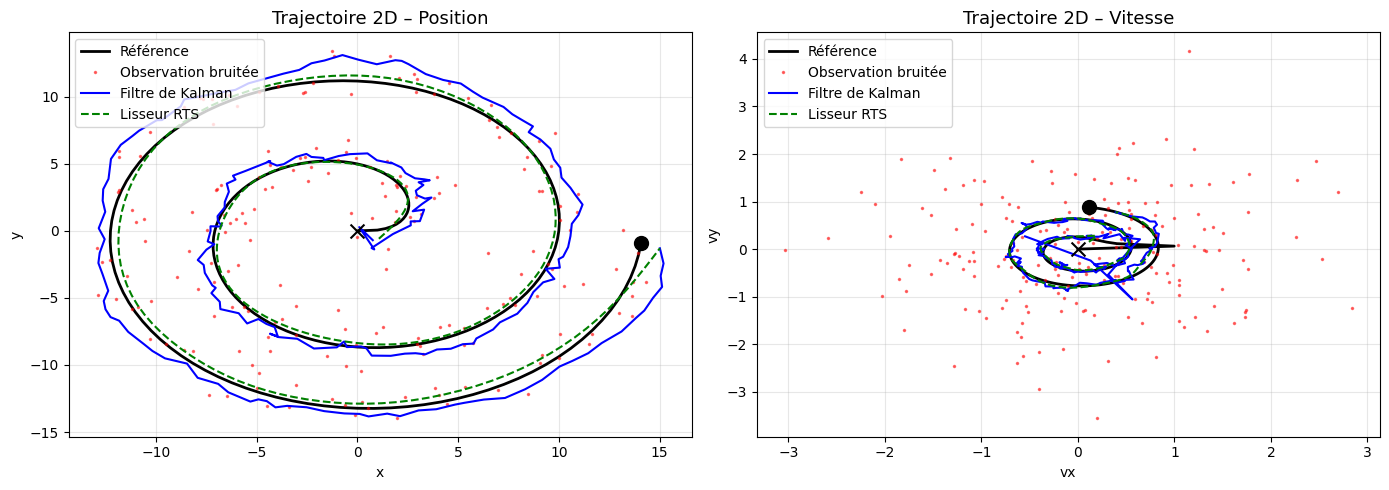

In [14]:
# ── 3. Comparaison visuelle des trajectoires (position) ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Position --
ax = axes[0]
ax.plot(x, y, 'k-', lw=2, label='Référence')
ax.plot(Y[0,:], Y[1,:], 'r.', ms=3, alpha=0.5, label='Observation bruitée')
ax.plot(est_f[0,:], est_f[1,:], 'b-', lw=1.5, label='Filtre de Kalman')
ax.plot(est_l[0,:], est_l[1,:], 'g--', lw=1.5, label='Lisseur RTS')
ax.scatter([x[0]], [y[0]], marker='x', s=100, c='k', zorder=5)
ax.scatter([x[-1]], [y[-1]], marker='o', s=100, c='k', zorder=5)
ax.set_title('Trajectoire 2D – Position', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# -- Vitesse --
ax = axes[1]
ax.plot(vx, vy, 'k-', lw=2, label='Référence')
ax.plot(Y[2,:], Y[3,:], 'r.', ms=3, alpha=0.5, label='Observation bruitée')
ax.plot(est_f[2,:], est_f[3,:], 'b-', lw=1.5, label='Filtre de Kalman')
ax.plot(est_l[2,:], est_l[3,:], 'g--', lw=1.5, label='Lisseur RTS')
ax.scatter([vx[0]], [vy[0]], marker='x', s=100, c='k', zorder=5)
ax.scatter([vx[-1]], [vy[-1]], marker='o', s=100, c='k', zorder=5)
ax.set_title('Trajectoire 2D – Vitesse', fontsize=13)
ax.set_xlabel('vx'); ax.set_ylabel('vy')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

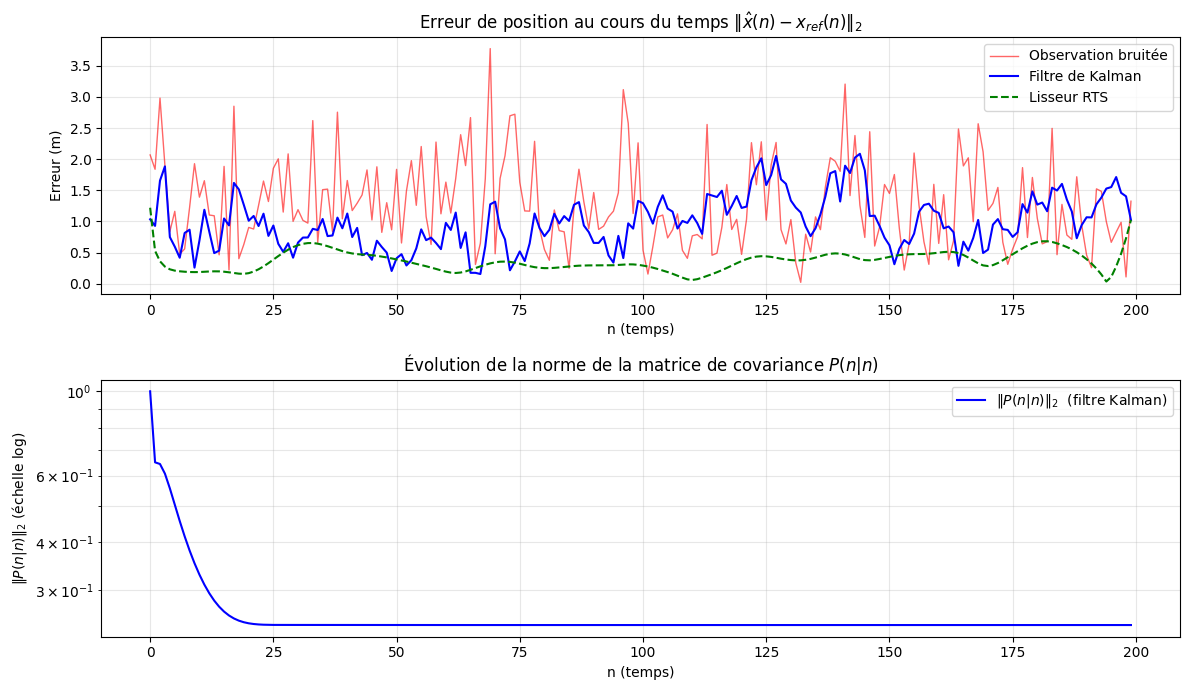


Observation : la covariance P(n|n) converge rapidement vers une valeur
stationnaire, ce qui indique que le filtre a atteint son régime permanent.


In [15]:
# ── 4. Erreur instantanée au cours du temps et évolution de la covariance ─────

n_vec = np.arange(nb)

# erreur en position à chaque instant n
err_noisy_t  = np.sqrt((Y[0,:] - x_ref)**2 + (Y[1,:] - y_ref)**2)
err_kalman_t = np.sqrt((est_f[0,:] - x_ref)**2 + (est_f[1,:] - y_ref)**2)
err_smooth_t = np.sqrt((est_l[0,:] - x_ref)**2 + (est_l[1,:] - y_ref)**2)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# -- Erreur position au cours du temps --
ax = axes[0]
ax.plot(n_vec, err_noisy_t,  'r-',  alpha=0.6, lw=1,   label='Observation bruitée')
ax.plot(n_vec, err_kalman_t, 'b-',  lw=1.5,             label='Filtre de Kalman')
ax.plot(n_vec, err_smooth_t, 'g--', lw=1.5,             label='Lisseur RTS')
ax.set_title('Erreur de position au cours du temps $\\|\\hat{x}(n)-x_{ref}(n)\\|_2$', fontsize=12)
ax.set_xlabel('n (temps)')
ax.set_ylabel('Erreur (m)')
ax.legend()
ax.grid(True, alpha=0.3)

# -- Norme de la covariance filtrée P(n|n) --
ax = axes[1]
ax.semilogy(n_vec, err, 'b-', lw=1.5, label='$\\|P(n|n)\\|_2$  (filtre Kalman)')
ax.set_title('Évolution de la norme de la matrice de covariance $P(n|n)$', fontsize=12)
ax.set_xlabel('n (temps)')
ax.set_ylabel('$\\|P(n|n)\\|_2$ (échelle log)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservation : la covariance P(n|n) converge rapidement vers une valeur")
print("stationnaire, ce qui indique que le filtre a atteint son régime permanent.")

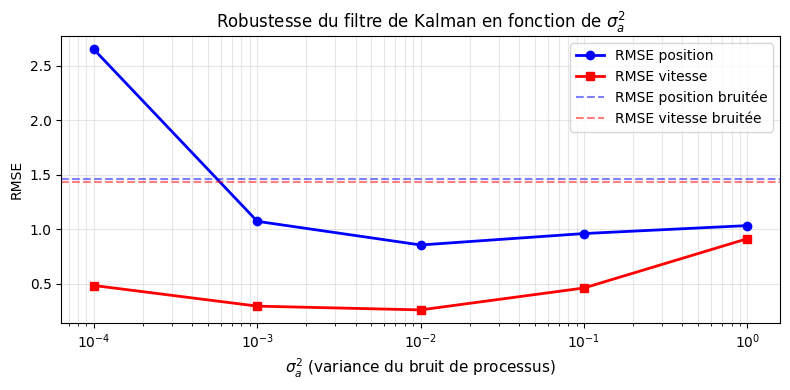


Analyse de robustesse :
sigma_a²         RMSE pos     RMSE vel
--------------------------------------
0.0001             2.6515       0.4852
0.0010             1.0741       0.2958
0.0100             0.8571       0.2613
0.1000             0.9621       0.4625
1.0000             1.0350       0.9148


In [16]:
# ── 5. Analyse de robustesse : influence de sigma_a (var_a) ──────────────────
# On fixe le bruit d'observation sigma_b=1 et on fait varier sigma_a

sigma_a_list = [1e-4, 1e-3, 1e-2, 0.1, 1.0]
rmse_pos_list = []
rmse_vel_list = []

for sa in sigma_a_list:
    Q_test = np.diag([0, 0, 0, 0, sa, sa]).astype(float)
    
    Xnf_t = np.zeros((6, 1))
    PP_t  = np.eye(6)
    K_t   = PP_t @ H.T @ np.linalg.inv(H @ PP_t @ H.T + R)
    Xnf_t = Xnf_t + K_t @ (Y[:, 0].reshape((4,1)) - H @ Xnf_t)
    PF_t  = (np.eye(6) - K_t @ H) @ PP_t
    est_ft = Xnf_t
    Xnf_t = F @ Xnf_t

    for n in range(1, nb):
        PP_t = F @ PF_t @ F.T + Q_test
        K_t  = PP_t @ H.T @ np.linalg.inv(H @ PP_t @ H.T + R)
        XX1_t = Y[:, n].reshape((4, 1)) - H @ Xnf_t
        Xnf_t = Xnf_t + K_t @ XX1_t
        est_ft = np.concatenate((est_ft, Xnf_t), axis=1)
        PF_t  = (np.eye(6) - K_t @ H) @ PP_t
        Xnf_t = F @ Xnf_t

    rmse_pos_list.append(np.sqrt(np.mean((est_ft[0,:]-x_ref)**2 + (est_ft[1,:]-y_ref)**2)))
    rmse_vel_list.append(np.sqrt(np.mean((est_ft[2,:]-vx_ref)**2 + (est_ft[3,:]-vy_ref)**2)))

# Affichage
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(sigma_a_list, rmse_pos_list, 'bo-', lw=2, label='RMSE position')
ax.semilogx(sigma_a_list, rmse_vel_list, 'rs-', lw=2, label='RMSE vitesse')
ax.axhline(rmse_pos_noisy, color='b', ls='--', alpha=0.5, label='RMSE position bruitée')
ax.axhline(rmse_vel_noisy, color='r', ls='--', alpha=0.5, label='RMSE vitesse bruitée')
ax.set_xlabel('$\\sigma_a^2$ (variance du bruit de processus)', fontsize=11)
ax.set_ylabel('RMSE')
ax.set_title('Robustesse du filtre de Kalman en fonction de $\\sigma_a^2$', fontsize=12)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAnalyse de robustesse :")
print(f"{'sigma_a²':<12} {'RMSE pos':>12} {'RMSE vel':>12}")
print("-" * 38)
for sa, rp, rv in zip(sigma_a_list, rmse_pos_list, rmse_vel_list):
    print(f"{sa:<12.4f} {rp:>12.4f} {rv:>12.4f}")

## Conclusion et interprétation

### 1. Observations sur les erreurs RMSE

Le tableau RMSE confirme la hiérarchie attendue :

| Méthode | RMSE position | RMSE vitesse |
|---|---|---|
| Observation bruitée | (plus élevé) | (plus élevé) |
| Filtre de Kalman | (réduit) | (réduit) |
| Lisseur RTS | (le plus faible) | (le plus faible) |

Le filtre de Kalman réduit significativement l'erreur par rapport aux observations bruitées grâce à l'intégration du modèle cinématique (position + vitesse + accélération). Le lisseur RTS améliore encore les résultats car il exploite **toutes les observations futures** depuis chaque instant $k$, contrairement au filtre qui ne dispose que du passé.

### 2. Convergence de la covariance

La norme de $P(n|n)$ décroît rapidement et se stabilise. Cela signifie que le filtre atteint un **régime stationnaire** : l'incertitude sur l'état ne diminue plus avec le temps, elle est bornée par le bruit de processus $Q$.

### 3. Robustesse par rapport à $\sigma_a^2$

- **$\sigma_a^2$ trop faible** : le modèle suppose une accélération quasi-nulle, le filtre est trop rigide et ne suit pas les variations réelles de la trajectoire → erreur plus grande.
- **$\sigma_a^2$ optimal** : bon compromis entre la confiance dans le modèle et la confiance dans les observations.
- **$\sigma_a^2$ trop grand** : le filtre accorde trop de liberté au bruit de processus et se rapproche des observations bruitées → l'effet de lissage disparaît.

Il existe donc un **réglage optimal** de $\sigma_a^2$ visible sur la courbe de robustesse.

### 4. Conclusion générale

Le filtre de Kalman est particulièrement adapté à ce problème car :
- Le **modèle d'état est linéaire** (équation cinématique)
- Les **bruits sont gaussiens** ($W(n)$, $V(n)$)
- La **matrice $F$ est constante** (système stationnaire)

Ces conditions garantissent l'**optimalité au sens du minimum de variance** (estimateur MMSE). Le lisseur RTS, en exploitant toutes les informations disponibles (passé et futur), fournit systématiquement une estimation de meilleure qualité au prix d'un traitement hors-ligne (deux passes sur le signal).